## Study Area: Mumbai
## Temperature Data : 1980-2025

In [27]:
import pandas as pd
import hvplot.pandas
import holoviews as hv
import matplotlib.pyplot as plt
print("Imports successful!")

Imports successful!


In [28]:
mumbai_url = ('https://www.ncei.noaa.gov/access/services/'
           'data/v1?dataset=daily-summaries'
           '&dataTypes=TAVG,PRCP&stations=IN012070800'
           '&startDate=1980-10-01&endDate=2025-08-24')
mumbai_url

'https://www.ncei.noaa.gov/access/services/data/v1?dataset=daily-summaries&dataTypes=TAVG,PRCP&stations=IN012070800&startDate=1980-10-01&endDate=2025-08-24'

In [29]:
mumbai_df= pd.read_csv(mumbai_url,
                       parse_dates=True,index_col="DATE")
mumbai_df

,STATION,PRCP,TAVG
DATE,,,
1980-10-01,IN012070800,0.0,283
1980-10-02,IN012070800,41.0,277
1980-10-03,IN012070800,109.0,283
1980-10-04,IN012070800,0.0,283
1980-10-05,IN012070800,0.0,284
...,...,...,...
2025-08-20,IN012070800,2090.0,268
2025-08-21,IN012070800,249.0,275
2025-08-22,IN012070800,30.0,274


<Axes: xlabel='DATE'>

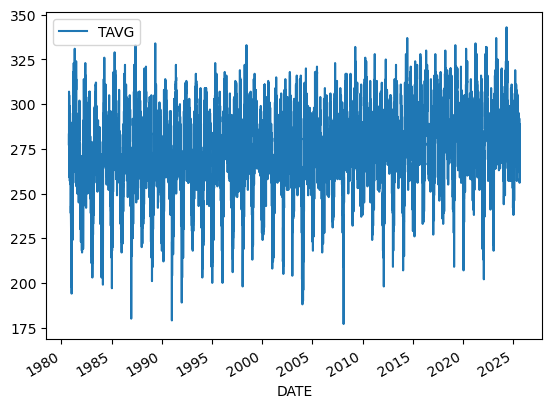

In [30]:
#ploting avg temperature data of Mumbai
mumbai_df.plot(y='TAVG')

In [31]:
mumbai_df["TAVG_C"] = mumbai_df["TAVG"] / 10
mumbai_df

,STATION,PRCP,TAVG,TAVG_C
DATE,,,,
1980-10-01,IN012070800,0.0,283,28.3
1980-10-02,IN012070800,41.0,277,27.7
1980-10-03,IN012070800,109.0,283,28.3
1980-10-04,IN012070800,0.0,283,28.3
1980-10-05,IN012070800,0.0,284,28.4
...,...,...,...,...
2025-08-20,IN012070800,2090.0,268,26.8
2025-08-21,IN012070800,249.0,275,27.5
2025-08-22,IN012070800,30.0,274,27.4


<Axes: xlabel='DATE'>

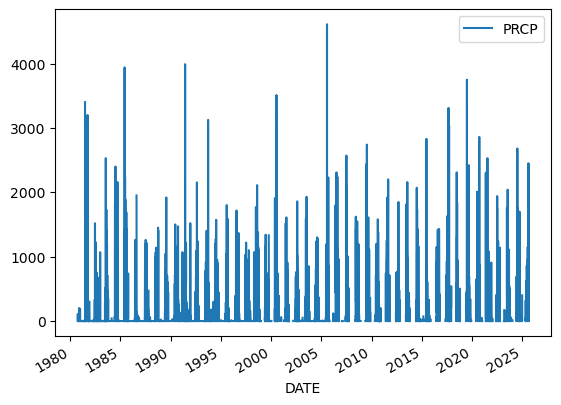

In [32]:
mumbai_df.plot(y='PRCP')

<Axes: xlabel='DATE'>

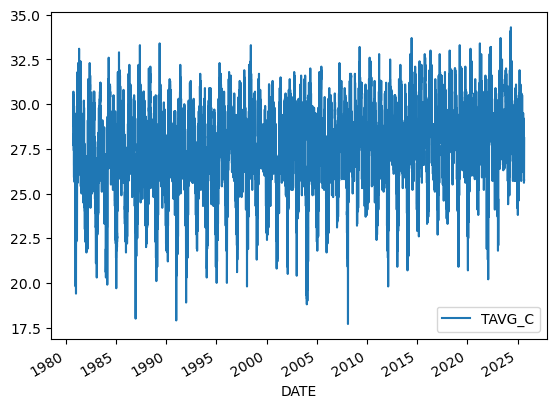

In [33]:
mumbai_df.plot(y='TAVG_C')

In [34]:
#Taking the TAVG_C Column only
mumbai_temp_df = mumbai_df[["TAVG_C"]]
mumbai_temp_df.head()

,TAVG_C
DATE,
1980-10-01,28.3
1980-10-02,27.7
1980-10-03,28.3
1980-10-04,28.3
1980-10-05,28.4


In [35]:
#Taking Annual Mean Temperature
ann_mean_temp_df = mumbai_temp_df.resample('YE').mean()
ann_mean_temp_df

,TAVG_C
DATE,
1980-12-31,26.789130
1981-12-31,27.355495
1982-12-31,27.201918
1983-12-31,26.412877
1984-12-31,27.060383
1985-12-31,26.978904
1986-12-31,27.127397
1987-12-31,27.775482
1988-12-31,27.215642


<Axes: title={'center': 'Average Temperature of Mumbai from 1980-2025'}, xlabel='DATE'>

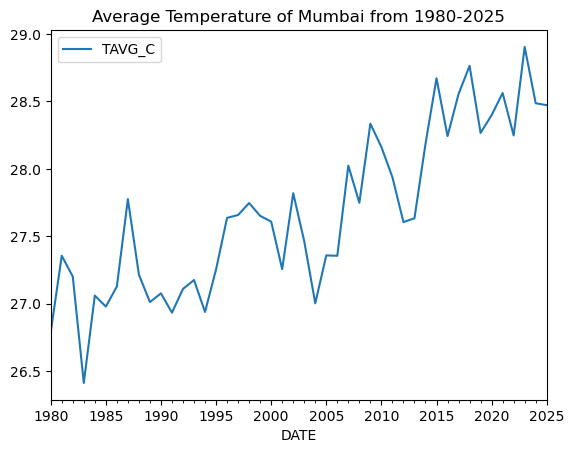

In [36]:
ann_mean_temp_df.plot(title='Average Temperature of Mumbai from 1980-2025')

In [37]:
#creating intercative plot
mumbai_plot = ann_mean_temp_df.hvplot(title='Average Temperature in Degree Celcius, Mumbai 1980-2025')
mumbai_plot

:Curve   [DATE]   (TAVG_C)

In [38]:
# Save the map as a file
hv.save(mumbai_plot,'mumbai_plot.html')

In [39]:
%%capture
%%bash
#Coverting to HTML
jupyter nbconvert Climate-gaurav.ipynb --to html